In [1]:
# Import libraries
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [2]:
# Transform
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load dataset
dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform)

# DataLoader (small batch)
loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)

In [3]:
# Generator
class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(100, 128),
            nn.ReLU(),

            nn.Linear(128, 256),
            nn.ReLU(),

            nn.Linear(256, 784),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z).view(-1, 1, 28, 28)

In [4]:
# Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(784, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),

            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.view(-1, 784)
        return self.model(x)

In [5]:
generator = Generator()
discriminator = Discriminator()

criterion = nn.BCELoss()

opt_g = torch.optim.Adam(generator.parameters(), lr=0.0002)
opt_d = torch.optim.Adam(discriminator.parameters(), lr=0.0002)

In [10]:
import torchvision.utils as vutils
import os

# Create folder to save images
os.makedirs("gan_images", exist_ok=True)

epochs = 5
g_losses = []
d_losses = []

for epoch in range(epochs):

    for real, _ in loader:
        
        batch_size = real.size(0)

        # Labels
        real_labels = torch.ones(batch_size, 1)
        fake_labels = torch.zeros(batch_size, 1)

        # -------------------
        # Train Discriminator
        # -------------------
        z = torch.randn(batch_size, 100)
        fake = generator(z)

        d_real = discriminator(real)
        d_fake = discriminator(fake.detach())

        loss_d = criterion(d_real, real_labels) + criterion(d_fake, fake_labels)

        opt_d.zero_grad()
        loss_d.backward()
        opt_d.step()

        # -------------------
        # Train Generator
        # -------------------
        z = torch.randn(batch_size, 100)
        fake = generator(z)

        d_fake = discriminator(fake)

        loss_g = criterion(d_fake, real_labels)

        opt_g.zero_grad()
        loss_g.backward()
        opt_g.step()

    # Store losses
    g_losses.append(loss_g.item())
    d_losses.append(loss_d.item())

    print(f"Epoch {epoch+1}, D Loss: {loss_d.item():.4f}, G Loss: {loss_g.item():.4f}")

    #SAVE IMAGES EVERY EPOCH
    z = torch.randn(16, 100)
    samples = generator(z).detach()

    vutils.save_image(
        samples,
        f"gan_images/epoch_{epoch+1}.png",
        nrow=4,
        normalize=True
    )

Epoch 1, D Loss: 0.3028, G Loss: 2.9510
Epoch 2, D Loss: 0.2436, G Loss: 3.3404
Epoch 3, D Loss: 0.3629, G Loss: 4.9314
Epoch 4, D Loss: 0.2567, G Loss: 3.1941
Epoch 5, D Loss: 0.3731, G Loss: 3.9074


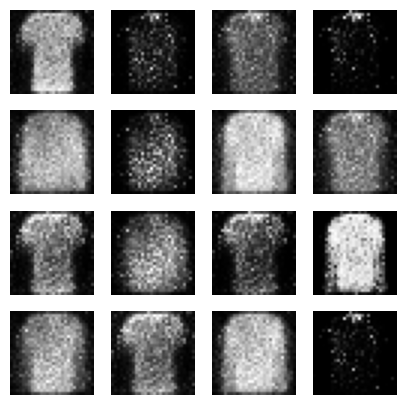

In [7]:
# Generate samples
z = torch.randn(16, 100)
samples = generator(z).detach()

# Plot images
fig, axes = plt.subplots(4, 4, figsize=(5,5))

for i, ax in enumerate(axes.flat):
    ax.imshow(samples[i].squeeze(), cmap='gray')
    ax.axis('off')

plt.show()

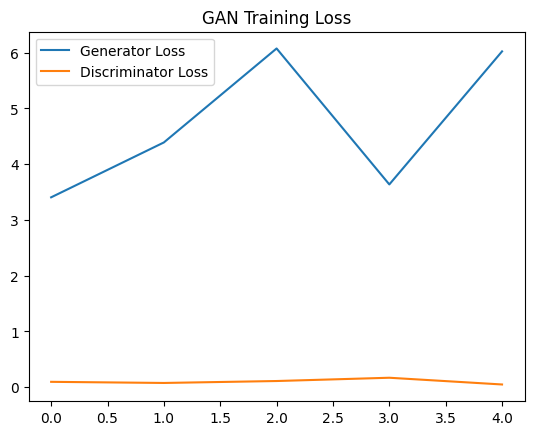

In [8]:
plt.plot(g_losses, label='Generator Loss')
plt.plot(d_losses, label='Discriminator Loss')
plt.legend()
plt.title("GAN Training Loss")
plt.show()